<div style="text-align:center; padding:18px 20px 8px 20px;">
  <div style="font-size:24px; font-weight:700; margin-bottom:4px;">
    Universidad Nacional del Centro del Perú
  </div>
  <div style="font-size:20px; font-weight:600; margin-bottom:16px;">
    Facultad de Economía
  </div>

  <img src="logo_economia.png" alt="Logo de la Facultad de Economía" width="180" style="margin:4px 0 16px 0;">

  <div style="font-size:27px; font-weight:700; line-height:1.28; max-width:900px; margin:0 auto;">
    Pass-through asimétrico del tipo de cambio al IPC importado en el Perú
  </div>
  <div style="font-size:19px; margin-top:7px;">
    Un análisis mediante NARDL (1996M1–2025M11)
  </div>

  <div style="margin-top:24px; font-size:16px; line-height:1.7;">
    <b>Cátedra:</b> Economía internacional<br>
    <b>Docente:</b> Mg. German Ccencho Pari
  </div>

  <div style="margin-top:18px; font-size:16px; line-height:1.65;">
    <b>Integrantes del grupo</b><br>
    Orellana Allpoc Joseph<br>
    Bartolo Artica Lizzie<br>
    Camarena Serpa Valeria<br>
    Espinoza Boza Yenifer
  </div>

  <div style="margin-top:22px; font-size:14px;">
    Este código y la base utilizada también se encuentran en el
    <a href="https://github.com/JosephOreAll/pass-through-asimetrico-peru">repositorio del proyecto</a>.
  </div>

  <div style="margin-top:14px; font-size:14px;">Huancayo, 2026</div>
</div>

<a id="indice" name="indice"></a>
## Índice

1. <a href="#objetivo-especificacion">Objetivo y especificación</a>  
2. <a href="#librerias-configuracion">Librerías y configuración</a>  
3. <a href="#importacion-renombrado">Importación y renombrado de variables</a>  
4. <a href="#preparacion-base">Preparación de la base</a>  
5. <a href="#descripcion-series">Descripción de las series</a>  
6. <a href="#raiz-unitaria">Pruebas de raíz unitaria</a>  
7. <a href="#nardl-uecm">Modelo NARDL en forma UECM</a>  
8. <a href="#estimacion-principal">Estimación con errores estándar HC1</a>  
9. <a href="#bounds-test">Prueba Bounds de cointegración</a>  
10. <a href="#largo-plazo-wald">Coeficientes de largo plazo y pruebas Wald</a>  
11. <a href="#diagnosticos">Diagnósticos del modelo</a>  
12. <a href="#multiplicadores">Multiplicadores dinámicos</a>  
13. <a href="#otros-tipos-cambio">¿Y si utilizamos otros tipos de cambio?</a>  
14. <a href="#exportacion">Resumen y exportación</a>

<a id="objetivo-especificacion" name="objetivo-especificacion"></a>
## 1. Objetivo y especificación

El objetivo es estimar si las depreciaciones y las apreciaciones del sol se transmiten de manera distinta al IPC importado. La variable dependiente es el logaritmo del IPC importado. El índice de precios nominales de importaciones se incorpora como control de los precios externos.

Sea $TC_t$ el logaritmo natural del tipo de cambio. Sus variaciones positivas y negativas se definen como:

$$
\Delta TC_t^{+}=\max(\Delta TC_t,0),
\qquad
\Delta TC_t^{-}=\min(\Delta TC_t,0).
$$

Las sumas parciales acumuladas son:

$$
TC_t^{+}=\sum_{j=1}^{t}\Delta TC_j^{+},
\qquad
TC_t^{-}=\sum_{j=1}^{t}\Delta TC_j^{-}.
$$

Como el tipo de cambio se expresa en soles por dólar, $TC_t^{+}$ representa depreciaciones acumuladas del sol y $TC_t^{-}$ representa apreciaciones acumuladas.

La relación de largo plazo es:

$$
\ln(IPCIMP_t)
=
\alpha_0
+
\alpha_1 TC_t^{+}
+
\alpha_2 TC_t^{-}
+
\alpha_3 \ln(IPM_{\mathrm{EXT},t})
+
u_t.
$$

La estimación se realiza con seis rezagos mensuales, efectos estacionales y variables dicotómicas para la crisis financiera internacional, la pandemia y el choque inflacionario de 2021–2022. La inferencia principal emplea errores estándar HC1.

<p style="text-align:right;"><a href="#indice">Volver al índice</a></p>

<a id="librerias-configuracion" name="librerias-configuracion"></a>
## 2. Librerías y configuración

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.ardl import UECM
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey,
    het_breuschpagan,
    linear_reset,
    breaks_cusumolsresid,
)
from statsmodels.stats.stattools import jarque_bera, durbin_watson

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ARCHIVO_DATOS = "DATA_MENSUAL.xlsx"
ARCHIVO_RESULTADOS = "RESULTADOS_NARDL_IPCIMPORTADO.xlsx"
REZAGOS = 6
HORIZONTE = 24

<a id="importacion-renombrado" name="importacion-renombrado"></a>
## 3. Importación y renombrado de variables

La base se importa directamente desde la hoja **Api**. Enseguida se reemplazan los nombres extensos por etiquetas breves que se utilizarán en todo el cuaderno.

In [2]:
df = pd.read_excel(ARCHIVO_DATOS, sheet_name="Api")

# Ubicación de las columnas por el texto final de cada nombre
col_fecha = df.columns[0]
col_tc_interb_prom = next(c for c in df.columns if str(c).strip().endswith("Interbancario - Promedio"))
col_tc_interb_venta = next(
    c for c in df.columns
    if str(c).strip().endswith("Interbancario - Venta")
)
col_tc_banc_venta = next(
    c for c in df.columns
    if str(c).strip().endswith("Bancario - Venta")
    and not str(c).strip().endswith("Interbancario - Venta")
)
col_ipm_ext = next(c for c in df.columns if "Precios Nominales" in str(c) and "Importaciones" in str(c))
col_ipcimp = next(c for c in df.columns if "IPC Importado" in str(c))

renombres = {
    col_fecha: "FECHA",
    col_tc_interb_prom: "TC_INTERB_PROM",
    col_tc_banc_venta: "TC_BANC_VENTA",
    col_tc_interb_venta: "TC_INTERB_VENTA",
    col_ipm_ext: "IPM_EXT",
    col_ipcimp: "IPCIMP",
}

df = df.rename(columns=renombres)
df = df[[
    "FECHA", "TC_INTERB_PROM", "TC_BANC_VENTA",
    "TC_INTERB_VENTA", "IPM_EXT", "IPCIMP"
]].copy()

df.head()

,FECHA,TC_INTERB_PROM,TC_BANC_VENTA,TC_INTERB_VENTA,IPM_EXT,IPCIMP
0,Ene.1996,2.349955,2.354273,2.353091,71.393442,36.882007
1,Feb.1996,2.354381,2.358905,2.356857,71.148874,37.002094
2,Mar.1996,2.356000,2.359810,2.358048,72.337333,37.151556
3,Abr.1996,2.364800,2.368450,2.366750,72.184612,37.506211
4,May.1996,2.410705,2.413955,2.412818,71.813967,37.999772


<a id="preparacion-base" name="preparacion-base"></a>
## 4. Preparación de la base

Se convierten las fechas mensuales del BCRP, se ordenan las observaciones y se verifican los valores numéricos. La especificación principal utiliza el tipo de cambio interbancario promedio.

In [3]:
meses = {
    "Ene": 1, "Feb": 2, "Mar": 3, "Abr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Ago": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dic": 12,
}


def convertir_fecha_bcrp(valor):
    if isinstance(valor, pd.Timestamp):
        return pd.Timestamp(valor.year, valor.month, 1)

    texto = str(valor).strip()
    coincidencia = re.match(r"([A-Za-zÁÉÍÓÚáéíóúñÑ]+)\.(\d{4})", texto)
    if coincidencia is None:
        return pd.NaT

    mes = meses[coincidencia.group(1)[:3].capitalize()]
    anio = int(coincidencia.group(2))
    return pd.Timestamp(anio, mes, 1)


df["FECHA"] = df["FECHA"].apply(convertir_fecha_bcrp)

columnas_numericas = [
    "TC_INTERB_PROM", "TC_BANC_VENTA", "TC_INTERB_VENTA",
    "IPM_EXT", "IPCIMP",
]

df[columnas_numericas] = df[columnas_numericas].apply(
    lambda columna: pd.to_numeric(columna, errors="coerce")
)

df = df.dropna(subset=["FECHA"]).sort_values("FECHA").set_index("FECHA").asfreq("MS")

print(f"Periodo: {df.index.min():%Y-%m} a {df.index.max():%Y-%m}")
print(f"Observaciones mensuales: {len(df)}")
df.head()

Periodo: 1996-01 a 2025-11
Observaciones mensuales: 359


,TC_INTERB_PROM,TC_BANC_VENTA,TC_INTERB_VENTA,IPM_EXT,IPCIMP
FECHA,,,,,
1996-01-01,2.349955,2.354273,2.353091,71.393442,36.882007
1996-02-01,2.354381,2.358905,2.356857,71.148874,37.002094
1996-03-01,2.356000,2.359810,2.358048,72.337333,37.151556
1996-04-01,2.364800,2.368450,2.366750,72.184612,37.506211
1996-05-01,2.410705,2.413955,2.412818,71.813967,37.999772


In [4]:
def preparar_variables(datos, columna_tc):
    base = datos[[columna_tc, "IPM_EXT", "IPCIMP"]].copy()
    base = base.rename(columns={columna_tc: "TC"})

    base["lnTC"] = np.log(base["TC"])
    base["lnIPM_EXT"] = np.log(base["IPM_EXT"])
    base["lnIPCIMP"] = np.log(base["IPCIMP"])

    base["d_lnTC"] = base["lnTC"].diff()
    base["d_lnTC_pos"] = base["d_lnTC"].clip(lower=0)
    base["d_lnTC_neg"] = base["d_lnTC"].clip(upper=0)
    base["lnTC_POS_cum"] = base["d_lnTC_pos"].fillna(0).cumsum()
    base["lnTC_NEG_cum"] = base["d_lnTC_neg"].fillna(0).cumsum()

    base["d_lnIPCIMP"] = base["lnIPCIMP"].diff()
    base["d_lnIPM_EXT"] = base["lnIPM_EXT"].diff()

    base["D_Crisis_2008_09"] = (
        (base.index >= "2008-09-01") & (base.index <= "2009-06-01")
    ).astype(int)
    base["D_Covid"] = (
        (base.index >= "2020-03-01") & (base.index <= "2020-12-01")
    ).astype(int)
    base["D_Shock_2021_22"] = (
        (base.index >= "2021-01-01") & (base.index <= "2022-12-01")
    ).astype(int)

    return base


base = preparar_variables(df, "TC_INTERB_PROM")
base.head()

,TC,IPM_EXT,IPCIMP,lnTC,lnIPM_EXT,lnIPCIMP,d_lnTC,d_lnTC_pos,d_lnTC_neg,lnTC_POS_cum,lnTC_NEG_cum,d_lnIPCIMP,d_lnIPM_EXT,D_Crisis_2008_09,D_Covid,D_Shock_2021_22
FECHA,,,,,,,,,,,,,,,,
1996-01-01,2.349955,71.393442,36.882007,0.854396,4.268206,3.607724,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0,0,0
1996-02-01,2.354381,71.148874,37.002094,0.856278,4.264774,3.610974,0.001882,0.001882,0.000000,0.001882,0.000000,0.003251,-0.003432,0,0,0
1996-03-01,2.356000,72.337333,37.151556,0.856965,4.281340,3.615006,0.000687,0.000687,0.000000,0.002569,0.000000,0.004031,0.016566,0,0,0
1996-04-01,2.364800,72.184612,37.506211,0.860693,4.279227,3.624507,0.003728,0.003728,0.000000,0.006297,0.000000,0.009501,-0.002113,0,0,0
1996-05-01,2.410705,71.813967,37.999772,0.879919,4.274079,3.637580,0.019226,0.019226,0.000000,0.025523,0.000000,0.013074,-0.005148,0,0,0


<a id="descripcion-series" name="descripcion-series"></a>
## 5. Descripción de las series

El IPC importado y el índice de precios nominales de importaciones se expresan como índices. Los tres tipos de cambio están medidos en soles por dólar estadounidense.

In [5]:
resumen_descriptivo = df[[
    "IPCIMP", "IPM_EXT", "TC_INTERB_PROM",
    "TC_BANC_VENTA", "TC_INTERB_VENTA",
]].describe().T

resumen_descriptivo

,count,mean,std,min,25%,50%,75%,max
IPCIMP,359.000000,70.343530,19.808369,36.882007,54.430033,71.106860,80.678793,109.231086
IPM_EXT,359.000000,100.707522,25.334176,60.248797,71.675457,106.634472,123.054089,152.504013
TC_INTERB_PROM,359.000000,3.230981,0.385263,2.349955,2.868348,3.288719,3.484373,4.108055
TC_BANC_VENTA,359.000000,3.232664,0.385702,2.354273,2.868777,3.289619,3.485282,4.110636
TC_INTERB_VENTA,359.000000,3.232240,0.385204,2.353091,2.869553,3.289729,3.484646,4.108932


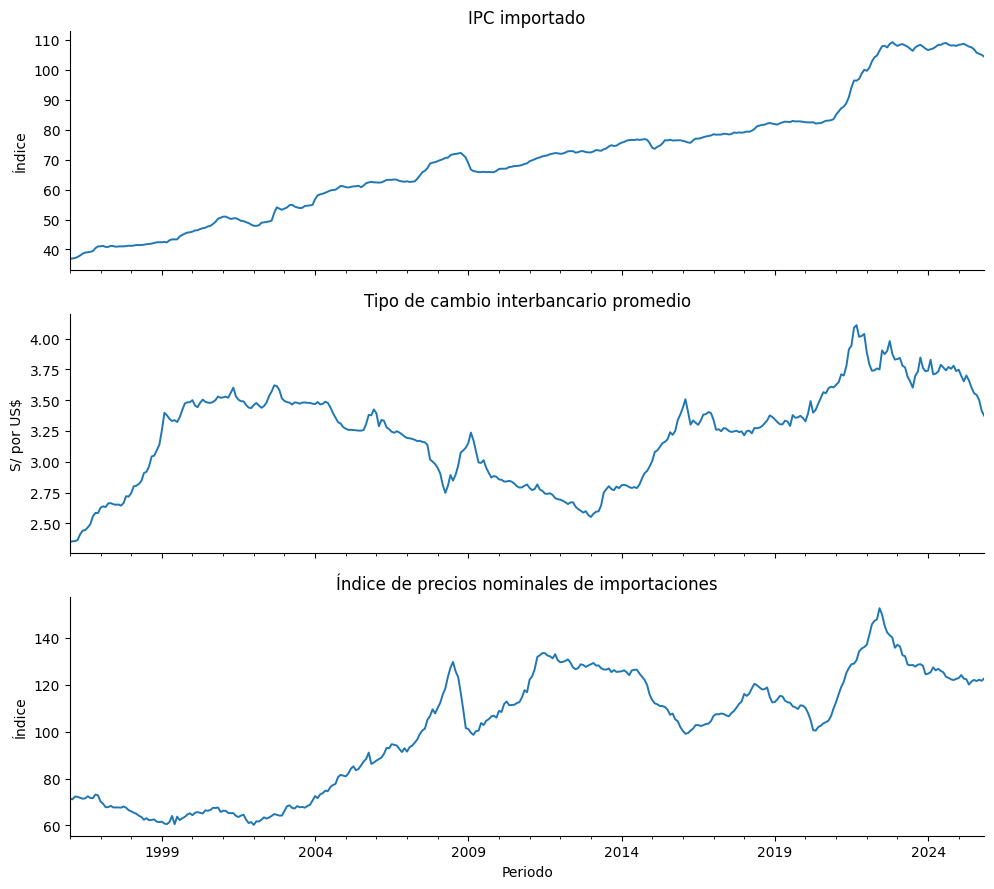

In [6]:
fig, ejes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

base["IPCIMP"].plot(ax=ejes[0], linewidth=1.4)
ejes[0].set_title("IPC importado")
ejes[0].set_ylabel("Índice")

base["TC"].plot(ax=ejes[1], linewidth=1.4)
ejes[1].set_title("Tipo de cambio interbancario promedio")
ejes[1].set_ylabel("S/ por US$")

base["IPM_EXT"].plot(ax=ejes[2], linewidth=1.4)
ejes[2].set_title("Índice de precios nominales de importaciones")
ejes[2].set_ylabel("Índice")
ejes[2].set_xlabel("Periodo")

plt.tight_layout()
plt.show()

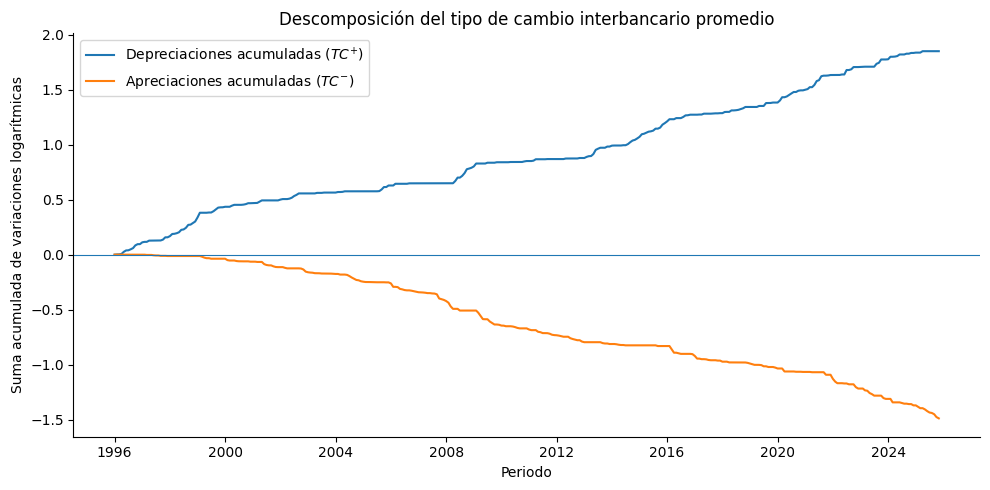

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(base.index, base["lnTC_POS_cum"], label="Depreciaciones acumuladas ($TC^{+}$)")
plt.plot(base.index, base["lnTC_NEG_cum"], label="Apreciaciones acumuladas ($TC^{-}$)")
plt.axhline(0, linewidth=0.8)
plt.title("Descomposición del tipo de cambio interbancario promedio")
plt.ylabel("Suma acumulada de variaciones logarítmicas")
plt.xlabel("Periodo")
plt.legend()
plt.tight_layout()
plt.show()

<a id="raiz-unitaria" name="raiz-unitaria"></a>
## 6. Pruebas de raíz unitaria

El enfoque ARDL/NARDL admite variables $I(0)$ e $I(1)$, pero no variables $I(2)$. Se aplican las pruebas ADF y KPSS en niveles y primeras diferencias. En ADF, la hipótesis nula plantea raíz unitaria; en KPSS, la hipótesis nula plantea estacionariedad.

In [8]:
def pruebas_raiz(serie, nombre):
    nivel = serie.dropna()
    diferencia = nivel.diff().dropna()

    adf_nivel = adfuller(nivel, autolag="AIC")
    adf_diferencia = adfuller(diferencia, autolag="AIC")
    kpss_nivel = kpss(nivel, regression="c", nlags="auto")
    kpss_diferencia = kpss(diferencia, regression="c", nlags="auto")

    return {
        "Variable": nombre,
        "ADF nivel": adf_nivel[0],
        "p ADF nivel": adf_nivel[1],
        "ADF primera diferencia": adf_diferencia[0],
        "p ADF diferencia": adf_diferencia[1],
        "KPSS nivel": kpss_nivel[0],
        "p KPSS nivel": kpss_nivel[1],
        "KPSS primera diferencia": kpss_diferencia[0],
        "p KPSS diferencia": kpss_diferencia[1],
    }


raiz_unitaria = pd.DataFrame([
    pruebas_raiz(base["lnIPCIMP"], "lnIPCIMP"),
    pruebas_raiz(base["lnTC"], "lnTC"),
    pruebas_raiz(base["lnIPM_EXT"], "lnIPM_EXT"),
])

raiz_unitaria

,Variable,ADF nivel,p ADF nivel,ADF primera diferencia,p ADF diferencia,KPSS nivel,p KPSS nivel,KPSS primera diferencia,p KPSS diferencia
0,lnIPCIMP,-1.356106,0.603129,-5.617447,0.000001,2.898952,0.010000,0.176502,0.100000
1,lnTC,-2.616127,0.089710,-8.120643,0.000000,0.762390,0.010000,0.277616,0.100000
2,lnIPM_EXT,-1.110403,0.710906,-8.682101,0.000000,2.425953,0.010000,0.106213,0.100000


<a id="nardl-uecm" name="nardl-uecm"></a>
## 7. Modelo NARDL en forma UECM

La variable dependiente es $\Delta\ln(IPCIMP_t)$. Los términos en nivel rezagados permiten recuperar la relación de largo plazo, mientras que las primeras diferencias recogen la dinámica mensual.

La forma general estimada es:

$$
\begin{aligned}
\Delta \ln(IPCIMP_t)
={}&\beta_0
+\rho\ln(IPCIMP_{t-1})
+\theta^{+}TC^{+}_{t-1}
+\theta^{-}TC^{-}_{t-1}
+\phi\ln(IPM_{\mathrm{EXT},t-1}) \\
&+\sum_{i=1}^{p-1}\lambda_i\Delta\ln(IPCIMP_{t-i})
+\sum_{i=0}^{q-1}\gamma_i^{+}\Delta TC^{+}_{t-i}
+\sum_{i=0}^{q-1}\gamma_i^{-}\Delta TC^{-}_{t-i} \\
&+\sum_{i=0}^{r-1}\delta_i\Delta\ln(IPM_{\mathrm{EXT},t-i})
+\Psi D_t
+\varepsilon_t.
\end{aligned}
$$

Un valor negativo y significativo de $\rho$ indica que los desvíos respecto del equilibrio se corrigen con el paso de los meses.

In [9]:
def estimar_nardl(base_modelo, rezagos=6):
    X = pd.DataFrame(index=base_modelo.index)
    y = base_modelo["d_lnIPCIMP"]

    # Componentes de largo plazo
    X["lnIPCIMP_l1"] = base_modelo["lnIPCIMP"].shift(1)
    X["lnTC_POS_l1"] = base_modelo["lnTC_POS_cum"].shift(1)
    X["lnTC_NEG_l1"] = base_modelo["lnTC_NEG_cum"].shift(1)
    X["lnIPM_EXT_l1"] = base_modelo["lnIPM_EXT"].shift(1)

    # Componentes de corto plazo
    for i in range(1, rezagos):
        X[f"d_lnIPCIMP_l{i}"] = base_modelo["d_lnIPCIMP"].shift(i)

    for i in range(rezagos):
        X[f"d_lnTC_pos_l{i}"] = base_modelo["d_lnTC_pos"].shift(i)
        X[f"d_lnTC_neg_l{i}"] = base_modelo["d_lnTC_neg"].shift(i)
        X[f"d_lnIPM_EXT_l{i}"] = base_modelo["d_lnIPM_EXT"].shift(i)

    estacionales = pd.get_dummies(
        base_modelo.index.month,
        prefix="mes",
        drop_first=True,
        dtype=int,
    )
    estacionales.index = base_modelo.index
    X = pd.concat([X, estacionales], axis=1)

    controles = ["D_Crisis_2008_09", "D_Covid", "D_Shock_2021_22"]
    X[controles] = base_modelo[controles]

    muestra = pd.concat([y.rename("d_lnIPCIMP"), X], axis=1).dropna()
    y_modelo = muestra["d_lnIPCIMP"]
    X_modelo = sm.add_constant(muestra.drop(columns="d_lnIPCIMP"))

    modelo_ols = sm.OLS(y_modelo, X_modelo).fit()
    modelo_hc1 = sm.OLS(y_modelo, X_modelo).fit(cov_type="HC1")

    base_bounds = base_modelo[[
        "lnIPCIMP", "lnTC_POS_cum", "lnTC_NEG_cum", "lnIPM_EXT",
        "D_Crisis_2008_09", "D_Covid", "D_Shock_2021_22",
    ]].dropna()

    uecm_bounds = UECM(
        base_bounds["lnIPCIMP"],
        lags=rezagos,
        exog=base_bounds[["lnTC_POS_cum", "lnTC_NEG_cum", "lnIPM_EXT"]],
        order=rezagos,
        trend="c",
        fixed=base_bounds[controles],
        seasonal=True,
        period=12,
        missing="drop",
    ).fit(cov_type="HC1")

    bounds = uecm_bounds.bounds_test(case=3, cov_type="HC1")

    rho = modelo_hc1.params["lnIPCIMP_l1"]
    largo_plazo = {
        "Depreciaciones": -modelo_hc1.params["lnTC_POS_l1"] / rho,
        "Apreciaciones": -modelo_hc1.params["lnTC_NEG_l1"] / rho,
        "Precios externos": -modelo_hc1.params["lnIPM_EXT_l1"] / rho,
    }

    suma_pos = " + ".join(f"d_lnTC_pos_l{i}" for i in range(rezagos))
    suma_neg = " + ".join(f"d_lnTC_neg_l{i}" for i in range(rezagos))

    wald_largo = modelo_hc1.wald_test(
        "lnTC_POS_l1 = lnTC_NEG_l1",
        scalar=True,
    )
    wald_corto = modelo_hc1.wald_test(
        f"{suma_pos} = {suma_neg}",
        scalar=True,
    )

    return {
        "muestra": muestra,
        "ols": modelo_ols,
        "hc1": modelo_hc1,
        "bounds": bounds,
        "rho": rho,
        "largo_plazo": largo_plazo,
        "wald_largo": wald_largo,
        "wald_corto": wald_corto,
    }


resultado_principal = estimar_nardl(base, REZAGOS)
print(f"Observaciones utilizadas: {len(resultado_principal['muestra'])}")
print(f"Regresores, incluida la constante: {resultado_principal['muestra'].shape[1]}")

Observaciones utilizadas: 353
Regresores, incluida la constante: 42


<a id="estimacion-principal" name="estimacion-principal"></a>
## 8. Estimación con errores estándar HC1

Los coeficientes se estiman por mínimos cuadrados ordinarios. La tabla de inferencia utiliza la matriz de varianzas y covarianzas HC1.

In [10]:
modelo_ols = resultado_principal["ols"]
modelo_hc1 = resultado_principal["hc1"]
print(modelo_hc1.summary())

                            OLS Regression Results                            
Dep. Variable:             d_lnIPCIMP   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     8.470
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           3.47e-31
Time:                        16:57:39   Log-Likelihood:                 1354.5
No. Observations:                 353   AIC:                            -2625.
Df Residuals:                     311   BIC:                            -2463.
Df Model:                          41                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0351      0.019  

<a id="bounds-test" name="bounds-test"></a>
## 9. Prueba Bounds de cointegración

La prueba Bounds contrasta la ausencia de una relación de largo plazo. Se utiliza el caso 3, con constante no restringida y sin tendencia determinística. La decisión se toma con el p-value del límite superior.

In [11]:
bounds = resultado_principal["bounds"]

resultado_bounds = pd.DataFrame({
    "Indicador": [
        "F-statistic",
        "p-value límite inferior",
        "p-value límite superior",
    ],
    "Valor": [
        bounds.stat,
        bounds.p_values["lower"],
        bounds.p_values["upper"],
    ],
})

resultado_bounds

,Indicador,Valor
0,F-statistic,4.778317
1,p-value límite inferior,0.001496
2,p-value límite superior,0.015403


<a id="largo-plazo-wald" name="largo-plazo-wald"></a>
## 10. Coeficientes de largo plazo y pruebas Wald

Los coeficientes de largo plazo se calculan como:

$$
LR^{+}=-\frac{\theta^{+}}{\rho},
\qquad
LR^{-}=-\frac{\theta^{-}}{\rho},
\qquad
LR^{P}=-\frac{\phi}{\rho}.
$$

La prueba de largo plazo contrasta $H_0: LR^{+}=LR^{-}$. La prueba de corto plazo compara la suma de los coeficientes asociados a $\Delta TC_t^{+}$ y $\Delta TC_t^{-}$.

In [12]:
rho = resultado_principal["rho"]
largo = resultado_principal["largo_plazo"]
wald_largo = resultado_principal["wald_largo"]
wald_corto = resultado_principal["wald_corto"]

coef_largo_plazo = pd.DataFrame({
    "Variable": [
        "Depreciaciones acumuladas (TC+)",
        "Apreciaciones acumuladas (TC−)",
        "Precios externos",
    ],
    "Coeficiente": [
        largo["Depreciaciones"],
        largo["Apreciaciones"],
        largo["Precios externos"],
    ],
})

resultado_wald = pd.DataFrame({
    "Prueba": [
        "Asimetría de largo plazo",
        "Asimetría de corto plazo",
    ],
    "Estadístico": [
        float(wald_largo.statistic),
        float(wald_corto.statistic),
    ],
    "p-value": [
        float(wald_largo.pvalue),
        float(wald_corto.pvalue),
    ],
})

print(f"Término de corrección de errores: {rho:.6f}")
print(f"p-value del término de corrección: {modelo_hc1.pvalues['lnIPCIMP_l1']:.6f}")
display(coef_largo_plazo)
display(resultado_wald)

Término de corrección de errores: -0.038589
p-value del término de corrección: 0.000186


,Variable,Coeficiente
0,Depreciaciones acumuladas (TC+),0.876359
1,Apreciaciones acumuladas (TC−),0.693911
2,Precios externos,0.650437


,Prueba,Estadístico,p-value
0,Asimetría de largo plazo,5.112465,0.023755
1,Asimetría de corto plazo,0.448222,0.503180


<a id="diagnosticos" name="diagnosticos"></a>
## 11. Diagnósticos del modelo

Se revisan autocorrelación serial, heterocedasticidad, forma funcional, estabilidad y normalidad de los residuos. Para la heterocedasticidad se utiliza Breusch–Pagan y la tabla principal se estima con errores estándar HC1. El contraste White completo no se incluye porque su regresión auxiliar tendría más términos que observaciones y quedaría saturada.

In [13]:
bg = acorr_breusch_godfrey(modelo_ols, nlags=12)
bp = het_breuschpagan(modelo_ols.resid, modelo_ols.model.exog)
reset = linear_reset(modelo_ols, power=2, use_f=True)
cusum = breaks_cusumolsresid(
    modelo_ols.resid,
    ddof=int(modelo_ols.df_model) + 1,
)
jb = jarque_bera(modelo_ols.resid)

diagnosticos = pd.DataFrame({
    "Prueba": [
        "Durbin-Watson",
        "Breusch-Godfrey",
        "Breusch-Pagan",
        "Ramsey RESET",
        "CUSUM",
        "Jarque-Bera",
    ],
    "Estadístico": [
        durbin_watson(modelo_ols.resid),
        bg[0],
        bp[0],
        float(reset.statistic),
        cusum[0],
        jb[0],
    ],
    "p-value": [
        np.nan,
        bg[1],
        bp[1],
        float(reset.pvalue),
        cusum[1],
        jb[1],
    ],
})

diagnosticos

,Prueba,Estadístico,p-value
0,Durbin-Watson,2.003899,NaN
1,Breusch-Godfrey,12.834280,0.381200
2,Breusch-Pagan,39.351079,0.544049
3,Ramsey RESET,0.675555,0.411753
4,CUSUM,0.462231,0.983153
5,Jarque-Bera,"1,345.461859",0.000000


<a id="multiplicadores" name="multiplicadores"></a>
## 12. Multiplicadores dinámicos

Los multiplicadores muestran la respuesta acumulada del IPC importado frente a una depreciación de 1% y una apreciación de 1%, manteniendo los demás componentes constantes.

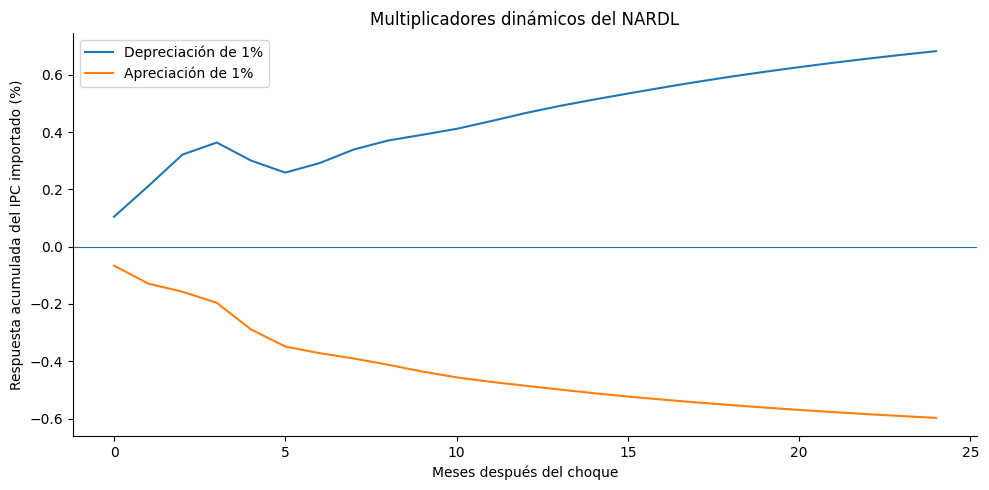

In [14]:
def respuesta_dinamica(parametros, tipo="positiva", horizonte=24, choque=0.01):
    dy = np.zeros(horizonte + 1)
    nivel_y = np.zeros(horizonte + 1)
    dx_pos = np.zeros(horizonte + 1)
    dx_neg = np.zeros(horizonte + 1)
    nivel_pos = np.zeros(horizonte + 1)
    nivel_neg = np.zeros(horizonte + 1)

    if tipo == "positiva":
        dx_pos[0] = choque
        nivel_pos[:] = choque
    else:
        dx_neg[0] = -choque
        nivel_neg[:] = -choque

    for t in range(horizonte + 1):
        y_l1 = nivel_y[t - 1] if t > 0 else 0
        pos_l1 = nivel_pos[t - 1] if t > 0 else 0
        neg_l1 = nivel_neg[t - 1] if t > 0 else 0

        cambio = parametros.get("lnIPCIMP_l1", 0) * y_l1
        cambio += parametros.get("lnTC_POS_l1", 0) * pos_l1
        cambio += parametros.get("lnTC_NEG_l1", 0) * neg_l1

        for i in range(1, REZAGOS):
            if t - i >= 0:
                cambio += parametros.get(f"d_lnIPCIMP_l{i}", 0) * dy[t - i]

        for i in range(REZAGOS):
            if t - i >= 0:
                cambio += parametros.get(f"d_lnTC_pos_l{i}", 0) * dx_pos[t - i]
                cambio += parametros.get(f"d_lnTC_neg_l{i}", 0) * dx_neg[t - i]

        dy[t] = cambio
        nivel_y[t] = (nivel_y[t - 1] if t > 0 else 0) + cambio

    return nivel_y * 100


respuesta_dep = respuesta_dinamica(modelo_hc1.params, "positiva", HORIZONTE)
respuesta_apr = respuesta_dinamica(modelo_hc1.params, "negativa", HORIZONTE)

multiplicadores = pd.DataFrame({
    "Mes": np.arange(HORIZONTE + 1),
    "Depreciación de 1%": respuesta_dep,
    "Apreciación de 1%": respuesta_apr,
})

plt.figure(figsize=(10, 5))
plt.plot(
    multiplicadores["Mes"],
    multiplicadores["Depreciación de 1%"],
    label="Depreciación de 1%",
)
plt.plot(
    multiplicadores["Mes"],
    multiplicadores["Apreciación de 1%"],
    label="Apreciación de 1%",
)
plt.axhline(0, linewidth=0.8)
plt.title("Multiplicadores dinámicos del NARDL")
plt.xlabel("Meses después del choque")
plt.ylabel("Respuesta acumulada del IPC importado (%)")
plt.legend()
plt.tight_layout()
plt.savefig("multiplicadores_dinamicos_nardl.png", dpi=300, bbox_inches="tight")
plt.show()

<a id="otros-tipos-cambio" name="otros-tipos-cambio"></a>
## 13. ¿Y si utilizamos otros tipos de cambio?

La misma especificación se estima con tres cotizaciones: interbancario promedio, bancario venta e interbancario venta. Se mantienen los seis rezagos, las variables estacionales, los controles por episodios y los errores estándar HC1. De esta manera se observa si los resultados centrales cambian al reemplazar la medida del tipo de cambio.

In [15]:
especificaciones = {
    "Interbancario promedio": "TC_INTERB_PROM",
    "Bancario venta": "TC_BANC_VENTA",
    "Interbancario venta": "TC_INTERB_VENTA",
}

filas_comparacion = []
resultados_por_tc = {}

for nombre, columna in especificaciones.items():
    base_tc = preparar_variables(df, columna)
    resultado_tc = estimar_nardl(base_tc, REZAGOS)
    resultados_por_tc[nombre] = resultado_tc

    filas_comparacion.append({
        "Tipo de cambio": nombre,
        "Observaciones": int(resultado_tc["hc1"].nobs),
        "ECM": resultado_tc["rho"],
        "p-value ECM": resultado_tc["hc1"].pvalues["lnIPCIMP_l1"],
        "Bounds F": resultado_tc["bounds"].stat,
        "Bounds p-value superior": resultado_tc["bounds"].p_values["upper"],
        "LR depreciaciones": resultado_tc["largo_plazo"]["Depreciaciones"],
        "LR apreciaciones": resultado_tc["largo_plazo"]["Apreciaciones"],
        "LR precios externos": resultado_tc["largo_plazo"]["Precios externos"],
        "Wald largo plazo p-value": float(resultado_tc["wald_largo"].pvalue),
        "Wald corto plazo p-value": float(resultado_tc["wald_corto"].pvalue),
    })

comparacion_tipos_cambio = pd.DataFrame(filas_comparacion)
comparacion_tipos_cambio

,Tipo de cambio,Observaciones,ECM,p-value ECM,Bounds F,Bounds p-value superior,LR depreciaciones,LR apreciaciones,LR precios externos,Wald largo plazo p-value,Wald corto plazo p-value
0,Interbancario promedio,353,-0.038589,0.000186,4.778317,0.015403,0.876359,0.693911,0.650437,0.023755,0.503180
1,Bancario venta,353,-0.038550,0.000177,4.802835,0.014814,0.878987,0.697079,0.652565,0.024300,0.493489
2,Interbancario venta,353,-0.038553,0.000186,4.776104,0.015457,0.877563,0.694857,0.650637,0.023878,0.498141


En las tres estimaciones, el p-value del límite superior del Bounds Test es menor que 0.05. Las pruebas Wald de largo plazo también presentan p-values menores que 0.05, mientras que las pruebas de corto plazo se mantienen por encima de 0.05. Por tanto, las tres cotizaciones respaldan cointegración y una respuesta asimétrica en el largo plazo, sin evidencia de asimetría de corto plazo.


<a id="exportacion" name="exportacion"></a>
## 14. Resumen y exportación

El archivo final reúne los resultados centrales del tipo de cambio interbancario promedio y el cuadro comparativo de las tres cotizaciones.

In [16]:
resumen_final = pd.DataFrame({
    "Indicador": [
        "Periodo inicial",
        "Periodo final",
        "Observaciones utilizadas",
        "Rezagos",
        "Término de corrección de errores",
        "p-value del ECM",
        "Bounds F-statistic",
        "Bounds p-value límite superior",
        "Coeficiente de largo plazo: depreciaciones",
        "Coeficiente de largo plazo: apreciaciones",
        "Coeficiente de largo plazo: precios externos",
        "Wald largo plazo p-value",
        "Wald corto plazo p-value",
    ],
    "Valor": [
        base.index.min().strftime("%Y-%m"),
        base.index.max().strftime("%Y-%m"),
        int(modelo_hc1.nobs),
        REZAGOS,
        rho,
        modelo_hc1.pvalues["lnIPCIMP_l1"],
        bounds.stat,
        bounds.p_values["upper"],
        largo["Depreciaciones"],
        largo["Apreciaciones"],
        largo["Precios externos"],
        float(wald_largo.pvalue),
        float(wald_corto.pvalue),
    ],
})

resumen_final

,Indicador,Valor
0,Periodo inicial,1996-01
1,Periodo final,2025-11
2,Observaciones utilizadas,353
3,Rezagos,6
4,Término de corrección de errores,-0.038589
5,p-value del ECM,0.000186
6,Bounds F-statistic,4.778317
7,Bounds p-value límite superior,0.015403
8,Coeficiente de largo plazo: depreciaciones,0.876359
9,Coeficiente de largo plazo: apreciaciones,0.693911


In [17]:
coeficientes_hc1 = pd.DataFrame({
    "Variable": modelo_hc1.params.index,
    "Coeficiente": modelo_hc1.params.values,
    "Error estándar HC1": modelo_hc1.bse.values,
    "Estadístico z": modelo_hc1.tvalues.values,
    "p-value": modelo_hc1.pvalues.values,
})

with pd.ExcelWriter(ARCHIVO_RESULTADOS, engine="openpyxl") as writer:
    resumen_final.to_excel(writer, sheet_name="Resumen", index=False)
    comparacion_tipos_cambio.to_excel(writer, sheet_name="Comparacion_TC", index=False)
    coef_largo_plazo.to_excel(writer, sheet_name="Largo_Plazo", index=False)
    resultado_wald.to_excel(writer, sheet_name="Pruebas_Wald", index=False)
    resultado_bounds.to_excel(writer, sheet_name="Bounds_Test", index=False)
    diagnosticos.to_excel(writer, sheet_name="Diagnosticos", index=False)
    raiz_unitaria.to_excel(writer, sheet_name="Raiz_Unitaria", index=False)
    coeficientes_hc1.to_excel(writer, sheet_name="Coeficientes_HC1", index=False)
    multiplicadores.to_excel(writer, sheet_name="Multiplicadores", index=False)

print(f"Resultados exportados en: {ARCHIVO_RESULTADOS}")
print("Gráfico exportado en: multiplicadores_dinamicos_nardl.png")

Resultados exportados en: RESULTADOS_NARDL_IPCIMPORTADO.xlsx
Gráfico exportado en: multiplicadores_dinamicos_nardl.png


### Cierre

La evidencia de cointegración se evalúa con el límite superior del Bounds Test. Los coeficientes de largo plazo cuantifican la respuesta acumulada del IPC importado. Las pruebas Wald permiten distinguir entre simetría y asimetría en el corto y largo plazo. Los diagnósticos complementan la evaluación de la especificación estimada.

<p style="text-align:right;"><a href="#indice">Volver al índice</a></p>